# Grating Coupler Surrogate Model

This notebook demonstrates building a neural network surrogate model for a 2D SOI grating coupler using Tidy3D simulations.

**Objective**: Train a model that predicts coupling efficiency as a function of:
- Grating pitch (period)
- Incident angle
- Optical frequency

**Device**: Standard 2D SOI grating coupler cross-section
- 220 nm silicon on SiO2 BOX
- 70 nm shallow etch depth
- 50% fill fraction
- 20 grating periods

## Setup and Imports

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web
import tidy3d.plugins.design as tdd
from tidy3d.plugins.mode import ModeSolver

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Enable caching for faster re-runs
td.config.local_cache.enabled = True

In [2]:
# Output directories
RESULTS_DIR = "results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
DATA_DIR = f"{RESULTS_DIR}/data"
SIM_DATA_DIR = f"{RESULTS_DIR}/sim_data"

for d in [FIGURES_DIR, DATA_DIR, SIM_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

## Device and Simulation Parameters

In [3]:
# Wavelength/frequency
lda0 = 1.55  # central wavelength (um)
freq0 = td.C_0 / lda0
ldas = np.linspace(1.5, 1.6, 101)  # wavelength range
freqs = td.C_0 / ldas
fwidth = 0.5 * (np.max(freqs) - np.min(freqs))

# Materials (non-dispersive at telecom)
n_si = 3.48
si = td.Medium(permittivity=n_si**2)
n_sio2 = 1.44
sio2 = td.Medium(permittivity=n_sio2**2)

# Geometry parameters
t_si = 0.22  # silicon thickness (um)
etch_depth = 0.07  # etch depth (um)
ff = 0.5  # filling fraction
t_box = 2.0  # BOX thickness (um)
t_tox = 0.5  # top oxide thickness (um)
n_periods = 20  # number of grating periods

# Fiber parameters
mfd = 10.4  # mode field diameter (um)

# Simulation domain
buffer = 1.0  # buffer around structures (um)
inf_eff = 1e3  # effective infinity

print(f"Device parameters:")
print(f"  Si thickness: {t_si*1000:.0f} nm")
print(f"  Etch depth: {etch_depth*1000:.0f} nm")
print(f"  Fill fraction: {ff}")

Device parameters:
  Si thickness: 220 nm
  Etch depth: 70 nm
  Fill fraction: 0.5


## Step 0: Calculate Effective Index

Before designing the grating, we need to calculate the effective index of the slab waveguide modes. This determines the optimal grating pitch via the grating equation:

$$\Lambda = \frac{\lambda_0}{n_{eff} - n_{clad} \sin(\theta)}$$

In [4]:
def solve_slab_neff(thickness: float) -> float:
    """Calculate effective index for a slab waveguide using ModeSolver."""
    slab = td.Structure(
        geometry=td.Box(center=(0, 0, thickness/2), size=(td.inf, td.inf, thickness)),
        medium=si,
    )
    top_clad = td.Structure(
        geometry=td.Box(center=(0, 0, thickness + 0.5), size=(td.inf, td.inf, 1.0)),
        medium=sio2,
    )
    bot_clad = td.Structure(
        geometry=td.Box(center=(0, 0, -0.5), size=(td.inf, td.inf, 1.0)),
        medium=sio2,
    )

    sim = td.Simulation(
        size=(1, 1, 2),
        center=(0, 0, thickness/2),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=40, wavelength=lda0),
        structures=[slab, top_clad, bot_clad],
        sources=[],
        run_time=1e-12,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
    )

    plane = td.Box(center=(0, 0, thickness/2), size=(0, 1, 2))
    mode_spec = td.ModeSpec(num_modes=1, target_neff=n_si)
    
    mode_solver = ModeSolver(
        simulation=sim, plane=plane, mode_spec=mode_spec, freqs=[freq0]
    )
    mode_data = mode_solver.solve()
    return float(np.real(mode_data.n_eff.values.item()))

In [5]:
# Solve for unetched and etched regions
print("Solving mode for unetched slab...")
n_eff_unetched = solve_slab_neff(t_si)
print(f"  n_eff (unetched, t={t_si*1000:.0f}nm): {n_eff_unetched:.4f}")

print("Solving mode for etched slab...")
t_etched = t_si - etch_depth
n_eff_etched = solve_slab_neff(t_etched)
print(f"  n_eff (etched, t={t_etched*1000:.0f}nm): {n_eff_etched:.4f}")

# Average effective index based on fill fraction
n_eff_avg = ff * n_eff_unetched + (1 - ff) * n_eff_etched
print(f"  n_eff (average, ff={ff}): {n_eff_avg:.4f}")

Solving mode for unetched slab...


15:01:55 EST WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'.                                

             WARNING: Mode field at frequency index 0, mode index 0 does not    
             decay at the plane boundaries.                                     

  n_eff (unetched, t=220nm): 2.8515
Solving mode for etched slab...


             WARNING: Mode field at frequency index 0, mode index 0 does not    
             decay at the plane boundaries.                                     

  n_eff (etched, t=150nm): 2.5436
  n_eff (average, ff=0.5): 2.6975


In [6]:
# Calculate optimal pitch and define sweep ranges
ANGLE_RANGE = (10, 25)  # degrees
ANGLE_CENTER = 15.0
N_PITCH = 22
N_ANGLE = 14

theta_center = np.deg2rad(ANGLE_CENTER)
pitch_optimal = lda0 / (n_eff_avg - n_sio2 * np.sin(theta_center))

print(f"\nOptimal pitch at theta={ANGLE_CENTER} deg:")
print(f"  Lambda = {lda0} / ({n_eff_avg:.3f} - {n_sio2}*sin({ANGLE_CENTER} deg))")
print(f"  = {pitch_optimal*1000:.0f} nm")

# Set pitch range centered on optimal
pitch_margin = 0.05  # +/-50nm
PITCH_RANGE = (pitch_optimal - pitch_margin, pitch_optimal + pitch_margin)

print(f"\nSweep ranges:")
print(f"  Pitch: {PITCH_RANGE[0]*1000:.0f}-{PITCH_RANGE[1]*1000:.0f} nm ({N_PITCH} points)")
print(f"  Angle: {ANGLE_RANGE[0]}-{ANGLE_RANGE[1]} deg ({N_ANGLE} points)")
print(f"  Total simulations: {N_PITCH * N_ANGLE}")


Optimal pitch at theta=15.0 deg:
  Lambda = 1.55 / (2.698 - 1.44*sin(15.0 deg))
  = 667 nm

Sweep ranges:
  Pitch: 617-717 nm (22 points)
  Angle: 10-25 deg (14 points)
  Total simulations: 308


## Simulation Function

Define the function that creates a grating coupler simulation for given pitch and angle parameters.

In [7]:
def make_grating_coupler_sim(pitch: float, theta_deg: float) -> td.Simulation:
    """
    Create a 2D grating coupler simulation.
    
    Args:
        pitch: Grating period in um
        theta_deg: Incident angle in degrees
    
    Returns:
        td.Simulation object
    """
    theta = np.deg2rad(theta_deg)
    l_grating = n_periods * pitch

    # Source position
    source_x = l_grating / 2
    source_z = t_si + t_tox + 0.5

    # Cladding structures
    tox = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, t_si),
            rmax=(inf_eff, inf_eff, t_si + t_tox)
        ),
        medium=sio2,
    )
    box = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, -t_box),
            rmax=(inf_eff, inf_eff, 0)
        ),
        medium=sio2,
    )
    substrate = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, -inf_eff),
            rmax=(inf_eff, inf_eff, -t_box)
        ),
        medium=si,
    )

    # Slab waveguide (extends to -x)
    slab_waveguide = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-inf_eff, -inf_eff, 0),
            rmax=(0, inf_eff, t_si)
        ),
        medium=si,
    )

    # Etched region base
    etched_base = td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(0, -inf_eff, 0),
            rmax=(inf_eff, inf_eff, t_si - etch_depth)
        ),
        medium=si,
    )

    # Grating teeth
    grating_geo = None
    for i in range(n_periods):
        tooth = td.Box(
            center=(i * pitch + ff * pitch / 2, 0, t_si - etch_depth / 2),
            size=(pitch * ff, td.inf, etch_depth)
        )
        grating_geo = tooth if grating_geo is None else grating_geo + tooth

    gratings = td.Structure(geometry=grating_geo, medium=si)

    # Gaussian beam source (fiber)
    source = td.GaussianBeam(
        size=(2 * mfd, td.inf, 0),
        center=(source_x, 0, source_z),
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        angle_theta=theta,
        direction="-",
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2,  # TE polarization
    )

    # Mode monitor at waveguide
    mode_monitor = td.ModeMonitor(
        center=(-buffer / 2, 0, t_si / 2),
        size=(0, td.inf, 6 * t_si),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=n_eff_unetched),
        name="mode",
    )

    # Simulation domain
    sim_size = (l_grating + 2 * buffer, 0, t_box + t_si + t_tox + 2 * buffer)
    sim_center = (l_grating / 2 - buffer / 2, 0, (t_si + t_tox - t_box) / 2)

    return td.Simulation(
        center=sim_center,
        size=sim_size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=25, wavelength=lda0),
        structures=[tox, gratings, etched_base, slab_waveguide, box, substrate],
        sources=[source],
        monitors=[mode_monitor],
        run_time=1.5e-12,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.periodic(),
            z=td.Boundary.pml(),
        ),
    )


def extract_coupling(sim_data: td.SimulationData) -> dict:
    """Extract coupling efficiency spectrum from simulation."""
    amps = sim_data["mode"].amps.sel(direction="-", mode_index=0)
    coupling = np.abs(amps.values) ** 2
    return {"coupling": coupling}

## Step 1: Test Single Simulation

Before running the full batch, verify the simulation works with a single test case.

Test parameters: pitch=667nm, angle=15.0 deg


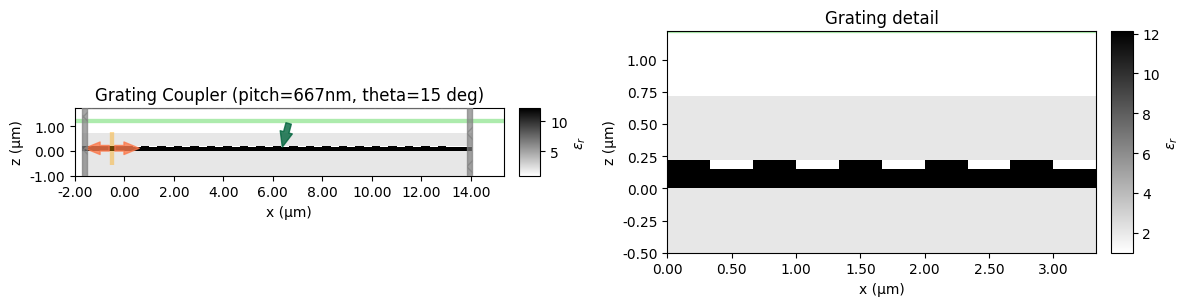

In [8]:
# Create test simulation at optimal parameters
test_pitch = pitch_optimal
test_angle = ANGLE_CENTER
print(f"Test parameters: pitch={test_pitch*1000:.0f}nm, angle={test_angle:.1f} deg")

test_sim = make_grating_coupler_sim(test_pitch, test_angle)

# Plot geometry
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
test_sim.plot_eps(y=0, ax=axes[0], freq=freq0)
axes[0].set_title(f"Grating Coupler (pitch={test_pitch*1000:.0f}nm, theta={test_angle:.0f} deg)")
axes[0].set_xlim(-2, n_periods * test_pitch + 2)
axes[0].set_ylim(-1, t_si + t_tox + 1)

test_sim.plot_eps(y=0, ax=axes[1], freq=freq0)
axes[1].set_title("Grating detail")
axes[1].set_xlim(0, 5 * test_pitch)
axes[1].set_ylim(-0.5, t_si + t_tox + 0.5)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_test_geometry.png", dpi=150)
plt.show()

In [9]:
# Run test simulation
print("Running test simulation...")
test_data = web.run(test_sim, task_name="GC_test", verbose=False)

# Extract and validate coupling
amps = test_data["mode"].amps.sel(direction="-", mode_index=0)
test_coupling = np.abs(amps.values) ** 2

print(f"Peak coupling: {test_coupling.max():.1%}")
assert test_coupling.max() > 0.01, "Coupling too low - check geometry"
assert test_coupling.max() <= 1.0, "Coupling > 100% - unphysical"

Running test simulation...
Peak coupling: 41.1%


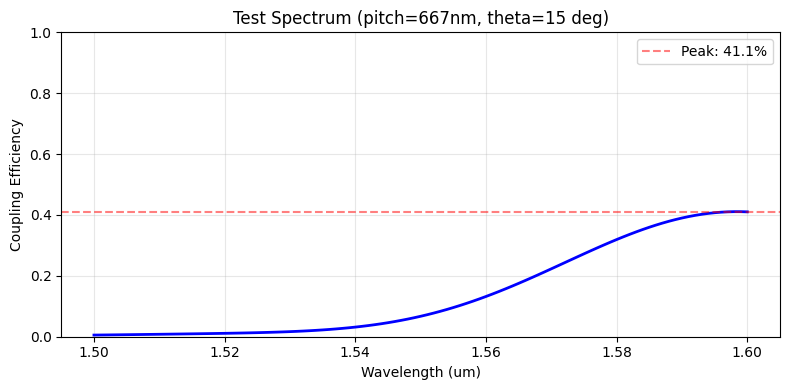

In [10]:
# Plot test spectrum
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ldas, test_coupling, 'b-', linewidth=2)
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Coupling Efficiency")
ax.set_title(f"Test Spectrum (pitch={test_pitch*1000:.0f}nm, theta={test_angle:.0f} deg)")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.axhline(test_coupling.max(), color='r', linestyle='--', alpha=0.5,
           label=f"Peak: {test_coupling.max():.1%}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_test_spectrum.png", dpi=150)
plt.show()

## Step 2: Run Batch Simulations

Use `tidy3d.plugins.design` to run a parameter sweep over pitch and angle.

In [11]:
param_pitch = tdd.ParameterFloat(name="pitch", span=PITCH_RANGE, num_points=N_PITCH)
param_angle = tdd.ParameterFloat(name="theta_deg", span=ANGLE_RANGE, num_points=N_ANGLE)

method = tdd.MethodGrid()

design_space = tdd.DesignSpace(
    parameters=[param_pitch, param_angle],
    method=method,
    task_name="GC_Surrogate",
    path_dir=SIM_DATA_DIR,
)

print(f"Running {N_PITCH * N_ANGLE} simulations...")
results = design_space.run(fn=make_grating_coupler_sim, fn_post=extract_coupling, verbose=True)
print(f"Batch complete: {len(results)} simulations")

Running 308 simulations...


15:04:23 EST Running 308 Simulations

Batch complete: 308 simulations


## Step 3: Extract and Process Data

In [12]:
df = results.to_dataframe()

# Build training data: (pitch, angle, freq) -> coupling
X_list = []
y_list = []

pitch_values = np.linspace(PITCH_RANGE[0], PITCH_RANGE[1], N_PITCH)
angle_values = np.linspace(ANGLE_RANGE[0], ANGLE_RANGE[1], N_ANGLE)

for _, row in df.iterrows():
    pitch = row["pitch"]
    angle = row["theta_deg"]
    coupling = row["coupling"]
    for i, freq in enumerate(freqs):
        X_list.append([pitch, angle, freq])
        y_list.append(coupling[i])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

print(f"Data extracted:")
print(f"  Samples: {len(X)}")
print(f"  Coupling range: [{y.min():.3f}, {y.max():.3f}]")

Data extracted:
  Samples: 31108
  Coupling range: [0.000, 0.435]


In [13]:
# Save training data
training_data = {
    "X": X, "y": y, "freqs": freqs, "ldas": ldas,
    "n_eff_unetched": n_eff_unetched,
    "n_eff_etched": n_eff_etched,
    "n_eff_avg": n_eff_avg,
    "pitch_optimal": pitch_optimal,
}
with open(f"{DATA_DIR}/training_data.pkl", "wb") as f:
    pickle.dump(training_data, f)
print(f"Saved training data to {DATA_DIR}/training_data.pkl")

Saved training data to results/data/training_data.pkl


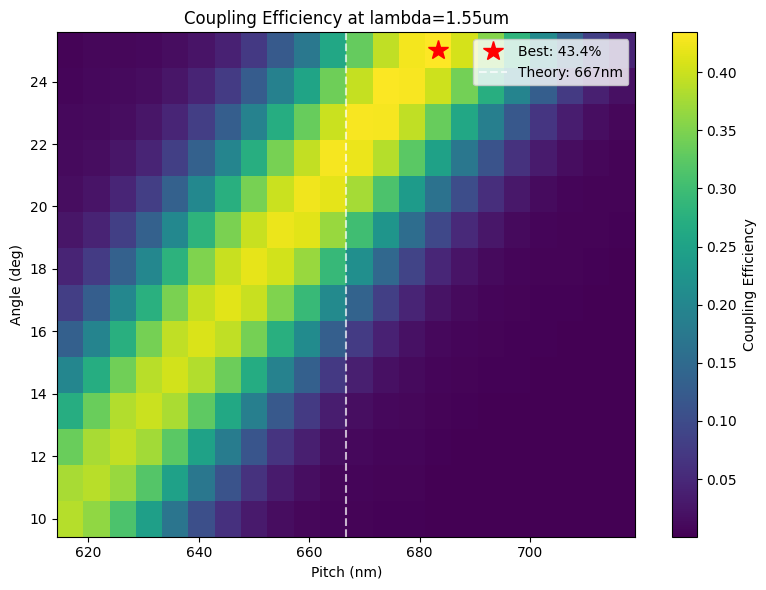

Best coupling at lambda=1550nm: 43.4%
  at pitch=683nm, angle=25.0 deg


In [14]:
# Plot design space heatmap at center wavelength
coupling_at_1550 = np.zeros((N_ANGLE, N_PITCH))
center_freq_idx = len(freqs) // 2

for _, row in df.iterrows():
    pitch_idx = np.argmin(np.abs(pitch_values - row["pitch"]))
    angle_idx = np.argmin(np.abs(angle_values - row["theta_deg"]))
    coupling_at_1550[angle_idx, pitch_idx] = row["coupling"][center_freq_idx]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(pitch_values * 1000, angle_values, coupling_at_1550, cmap="viridis", shading="auto")
plt.colorbar(im, ax=ax, label="Coupling Efficiency")
ax.set_xlabel("Pitch (nm)")
ax.set_ylabel("Angle (deg)")
ax.set_title(f"Coupling Efficiency at lambda={lda0}um")

# Mark maximum
max_idx = np.unravel_index(np.argmax(coupling_at_1550), coupling_at_1550.shape)
best_angle = angle_values[max_idx[0]]
best_pitch = pitch_values[max_idx[1]]
ax.plot(best_pitch * 1000, best_angle, 'r*', markersize=15, label=f"Best: {coupling_at_1550.max():.1%}")
ax.axvline(pitch_optimal * 1000, color='white', linestyle='--', alpha=0.7, label=f"Theory: {pitch_optimal*1000:.0f}nm")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_design_space.png", dpi=150)
plt.show()

print(f"Best coupling at lambda=1550nm: {coupling_at_1550.max():.1%}")
print(f"  at pitch={best_pitch*1000:.0f}nm, angle={best_angle:.1f} deg")

## Step 4: Neural Network Training

Train a simple feedforward network to predict coupling efficiency from (pitch, angle, frequency).

In [15]:
# Normalization parameters
X_min = np.array([PITCH_RANGE[0], ANGLE_RANGE[0], freqs.min()], dtype=np.float32)
X_max = np.array([PITCH_RANGE[1], ANGLE_RANGE[1], freqs.max()], dtype=np.float32)

def normalize(X, X_min, X_max):
    """Normalize to [-1, 1]."""
    return 2 * (X - X_min) / (X_max - X_min) - 1

X_norm = normalize(X, X_min, X_max)

# Train/val/test split (60/20/20)
n_samples = len(X)
indices = np.random.permutation(n_samples)
n_train = int(0.6 * n_samples)
n_val = int(0.2 * n_samples)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train, y_train = X_norm[train_idx], y[train_idx]
X_val, y_val = X_norm[val_idx], y[val_idx]
X_test, y_test = X_norm[test_idx], y[test_idx]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 18664, Val: 6221, Test: 6223


In [16]:
# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [17]:
class GratingSurrogate(nn.Module):
    """Simple feedforward network for coupling prediction."""
    
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


model = GratingSurrogate()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

GratingSurrogate(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [18]:
# Training loop with early stopping
n_epochs = 500
patience = 30
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

print("Training...")
for epoch in range(n_epochs):
    # Train
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_dataset)
    
    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            val_loss += loss.item() * len(X_batch)
    val_loss /= len(val_dataset)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), f"{DATA_DIR}/surrogate_model.pt")
    else:
        patience_counter += 1
    
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")
    
    if patience_counter >= patience:
        print(f"  Early stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load(f"{DATA_DIR}/surrogate_model.pt", weights_only=True))
print(f"Training complete. Best val loss: {best_val_loss:.6f}")

Training...
  Epoch 50: train_loss=0.000004, val_loss=0.000003
  Epoch 100: train_loss=0.000002, val_loss=0.000002
  Epoch 150: train_loss=0.000001, val_loss=0.000001
  Epoch 200: train_loss=0.000001, val_loss=0.000001
  Early stopping at epoch 243
Training complete. Best val loss: 0.000001


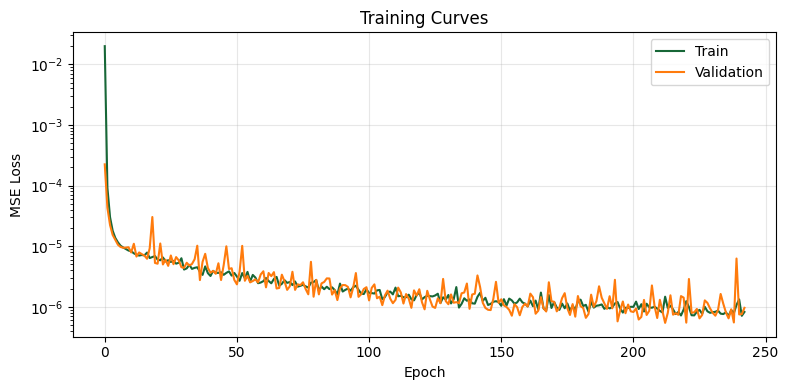

In [19]:
# Plot training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(train_losses, label="Train")
ax.semilogy(val_losses, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_training_curves.png", dpi=150)
plt.show()

## Step 5: Evaluate Model

In [20]:
model.eval()
with torch.no_grad():
    y_pred_test = model(torch.from_numpy(X_test)).numpy()

# Metrics
mse = np.mean((y_pred_test - y_test) ** 2)
mae = np.mean(np.abs(y_pred_test - y_test))
max_error = np.max(np.abs(y_pred_test - y_test))

print(f"Test Metrics (interpolation):")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.4f} ({mae*100:.1f}%)")
print(f"  Max Error: {max_error:.4f} ({max_error*100:.1f}%)")

Test Metrics (interpolation):
  MSE: 0.000001
  MAE: 0.0006 (0.1%)
  Max Error: 0.0036 (0.4%)


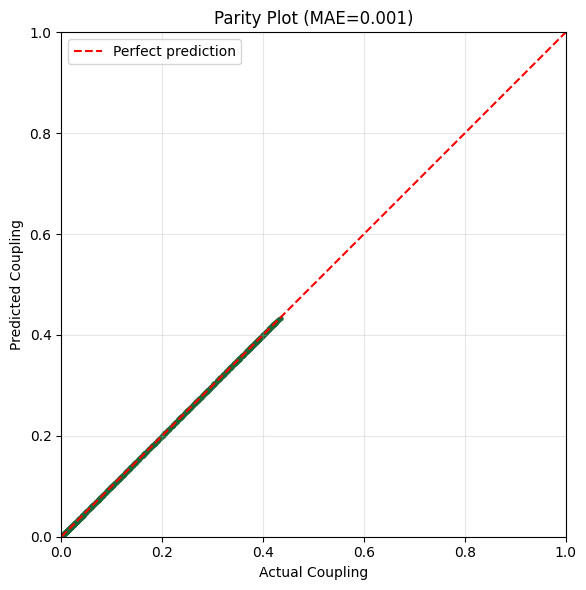

In [21]:
# Parity plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.3, s=5)
ax.plot([0, 1], [0, 1], 'r--', label="Perfect prediction")
ax.set_xlabel("Actual Coupling")
ax.set_ylabel("Predicted Coupling")
ax.set_title(f"Parity Plot (MAE={mae:.3f})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_parity_plot.png", dpi=150)
plt.show()

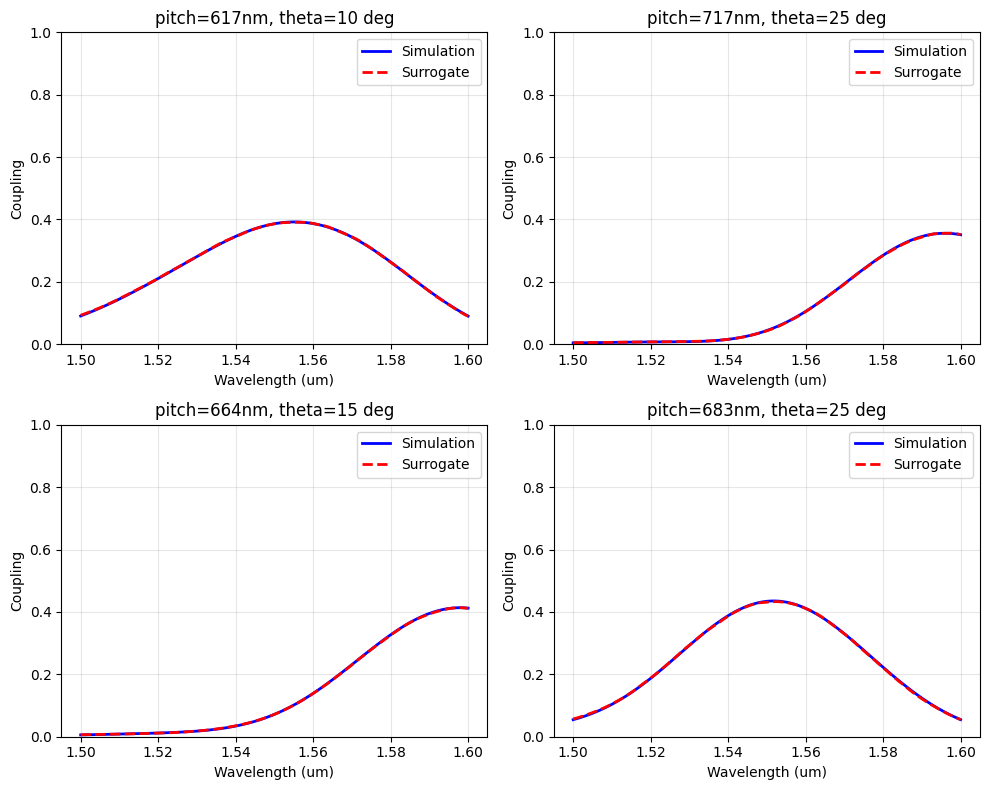

In [22]:
# Spectrum comparison for test cases
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

test_cases = [
    (PITCH_RANGE[0], ANGLE_RANGE[0]),  # corner
    (PITCH_RANGE[1], ANGLE_RANGE[1]),  # opposite corner
    (pitch_optimal, ANGLE_CENTER),  # theoretical optimum
    (best_pitch, best_angle),  # best from grid
]

for ax, (p, a) in zip(axes, test_cases):
    # Get actual spectrum
    dist = (df["pitch"] - p)**2 + ((df["theta_deg"] - a)/10)**2
    closest_idx = dist.idxmin()
    actual = df.loc[closest_idx, "coupling"]
    p_actual = df.loc[closest_idx, "pitch"]
    a_actual = df.loc[closest_idx, "theta_deg"]
    
    # Predict with surrogate
    X_pred = np.array([[p_actual, a_actual, f] for f in freqs], dtype=np.float32)
    X_pred_norm = normalize(X_pred, X_min, X_max)
    with torch.no_grad():
        predicted = model(torch.from_numpy(X_pred_norm)).numpy()
    
    ax.plot(ldas, actual, 'b-', linewidth=2, label="Simulation")
    ax.plot(ldas, predicted, 'r--', linewidth=2, label="Surrogate")
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Coupling")
    ax.set_title(f"pitch={p_actual*1000:.0f}nm, theta={a_actual:.0f} deg")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_spectrum_comparison.png", dpi=150)
plt.show()

## Step 6: Out-of-Sample Validation

The test MAE above is on held-out data from the same grid (interpolation). For true validation, we run NEW simulations at random parameter points not in the training set.

In [23]:
np.random.seed(42)
n_validation_sims = 5

# Random points within parameter range (but not on the grid)
val_pitches = np.random.uniform(PITCH_RANGE[0] + 0.005, PITCH_RANGE[1] - 0.005, n_validation_sims)
val_angles = np.random.uniform(ANGLE_RANGE[0] + 0.5, ANGLE_RANGE[1] - 0.5, n_validation_sims)

print(f"Running {n_validation_sims} NEW validation simulations...")

val_actual = []
val_predicted = []

for i, (p, a) in enumerate(zip(val_pitches, val_angles)):
    print(f"  Validation {i+1}/{n_validation_sims}: pitch={p*1000:.1f}nm, theta={a:.1f} deg")
    
    # Run actual simulation
    val_sim = make_grating_coupler_sim(p, a)
    val_data = web.run(val_sim, task_name=f"GC_val_{i}", verbose=False)
    
    # Get actual coupling at center frequency
    amps = val_data["mode"].amps.sel(direction="-", mode_index=0)
    actual_spectrum = np.abs(amps.values) ** 2
    actual_at_1550 = actual_spectrum[len(freqs)//2]
    
    # Get surrogate prediction
    X_val = np.array([[p, a, freq0]], dtype=np.float32)
    X_val_norm = normalize(X_val, X_min, X_max)
    with torch.no_grad():
        pred_at_1550 = model(torch.from_numpy(X_val_norm)).item()
    
    val_actual.append(actual_at_1550)
    val_predicted.append(pred_at_1550)
    
    print(f"    Actual: {actual_at_1550:.1%}, Predicted: {pred_at_1550:.1%}, Error: {abs(actual_at_1550 - pred_at_1550)*100:.1f}%")

Running 5 NEW validation simulations...
  Validation 1/5: pitch=655.4nm, theta=12.7 deg
    Actual: 7.5%, Predicted: 7.5%, Error: 0.0%
  Validation 2/5: pitch=707.3nm, theta=11.3 deg
    Actual: 0.1%, Predicted: 0.1%, Error: 0.0%
  Validation 3/5: pitch=687.6nm, theta=22.6 deg
    Actual: 26.4%, Predicted: 26.3%, Error: 0.1%
  Validation 4/5: pitch=675.6nm, theta=18.9 deg
    Actual: 16.9%, Predicted: 17.5%, Error: 0.7%
  Validation 5/5: pitch=635.8nm, theta=20.4 deg
    Actual: 13.2%, Predicted: 13.2%, Error: 0.1%


In [24]:
val_actual = np.array(val_actual)
val_predicted = np.array(val_predicted)

oos_mae = np.mean(np.abs(val_actual - val_predicted))
oos_max_error = np.max(np.abs(val_actual - val_predicted))

print(f"\nOut-of-sample validation (NEW simulations):")
print(f"  MAE: {oos_mae:.4f} ({oos_mae*100:.1f}%)")
print(f"  Max Error: {oos_max_error:.4f} ({oos_max_error*100:.1f}%)")
print(f"\nThis is the TRUE measure of surrogate accuracy!")


Out-of-sample validation (NEW simulations):
  MAE: 0.0017 (0.2%)
  Max Error: 0.0065 (0.7%)

This is the TRUE measure of surrogate accuracy!


## Step 7: Surrogate-Based Optimization

Use gradient descent on the surrogate model to find optimal (pitch, angle) at the center wavelength.

In [25]:
# Setup optimization in normalized space
X_min_torch = torch.tensor(X_min, dtype=torch.float32)
X_max_torch = torch.tensor(X_max, dtype=torch.float32)
freq_target_norm = 2 * (freq0 - X_min[2]) / (X_max[2] - X_min[2]) - 1

# Initialize at center of parameter space
params = torch.tensor([0.0, 0.0], dtype=torch.float32, requires_grad=True)
optimizer_opt = optim.Adam([params], lr=0.05)

opt_history = []
param_history = []

for i in range(200):
    optimizer_opt.zero_grad()
    
    pitch_norm = torch.clamp(params[0], -1.0, 1.0)
    angle_norm = torch.clamp(params[1], -1.0, 1.0)
    
    x_input = torch.stack([pitch_norm, angle_norm, torch.tensor(freq_target_norm)])
    coupling = model(x_input.unsqueeze(0))
    loss = -coupling  # Maximize
    
    loss.backward()
    optimizer_opt.step()
    
    # Convert to physical units
    pitch_phys = (pitch_norm.item() + 1) / 2 * (X_max[0] - X_min[0]) + X_min[0]
    angle_phys = (angle_norm.item() + 1) / 2 * (X_max[1] - X_min[1]) + X_min[1]
    
    opt_history.append(coupling.item())
    param_history.append((pitch_phys, angle_phys))

In [26]:
# Final optimized parameters
final_pitch_norm = torch.clamp(params[0], -1.0, 1.0).item()
final_angle_norm = torch.clamp(params[1], -1.0, 1.0).item()
opt_pitch = (final_pitch_norm + 1) / 2 * (X_max[0] - X_min[0]) + X_min[0]
opt_angle = (final_angle_norm + 1) / 2 * (X_max[1] - X_min[1]) + X_min[1]

print(f"Surrogate-optimized parameters:")
print(f"  Pitch: {opt_pitch*1000:.1f} nm")
print(f"  Angle: {opt_angle:.1f} deg")
print(f"  Predicted coupling: {opt_history[-1]:.1%}")

print(f"\nGrid search best:")
print(f"  Pitch: {best_pitch*1000:.0f} nm")
print(f"  Angle: {best_angle:.1f} deg")
print(f"  Coupling: {coupling_at_1550.max():.1%}")

print(f"\nTheoretical optimal (at theta={ANGLE_CENTER} deg):")
print(f"  Pitch: {pitch_optimal*1000:.0f} nm")

Surrogate-optimized parameters:
  Pitch: 658.3 nm
  Angle: 19.8 deg
  Predicted coupling: 42.6%

Grid search best:
  Pitch: 683 nm
  Angle: 25.0 deg
  Coupling: 43.4%

Theoretical optimal (at theta=15.0 deg):
  Pitch: 667 nm


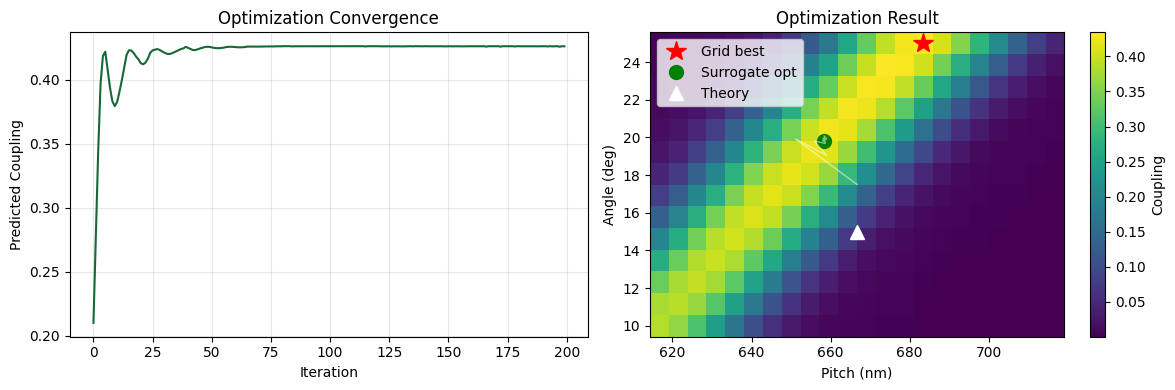

In [27]:
# Plot optimization results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(opt_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Predicted Coupling")
axes[0].set_title("Optimization Convergence")
axes[0].grid(True, alpha=0.3)

im = axes[1].pcolormesh(pitch_values * 1000, angle_values, coupling_at_1550, cmap="viridis", shading="auto")
plt.colorbar(im, ax=axes[1], label="Coupling")
axes[1].plot(best_pitch * 1000, best_angle, 'r*', markersize=15, label="Grid best")
axes[1].plot(opt_pitch * 1000, opt_angle, 'go', markersize=10, label="Surrogate opt")
axes[1].plot(pitch_optimal * 1000, ANGLE_CENTER, 'w^', markersize=10, label="Theory")

# Optimization trajectory
pitches = [p*1000 for p, a in param_history[::10]]
angles = [a for p, a in param_history[::10]]
axes[1].plot(pitches, angles, 'w-', alpha=0.5, linewidth=1)

axes[1].set_xlabel("Pitch (nm)")
axes[1].set_ylabel("Angle (deg)")
axes[1].set_title("Optimization Result")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_optimization.png", dpi=150)
plt.show()

## Summary

This notebook demonstrated:

1. **Mode solving** to calculate effective indices for accurate grating design
2. **Parameter sweep** using `tidy3d.plugins.design` for efficient batch simulations
3. **Neural network surrogate** training with PyTorch
4. **Out-of-sample validation** with NEW simulations to verify generalization
5. **Gradient-based optimization** using the differentiable surrogate

In [28]:
print("="*60)
print("SUMMARY")
print("="*60)
print(f"Mode solver: n_eff = {n_eff_avg:.3f}")
print(f"Theoretical optimal pitch: {pitch_optimal*1000:.0f} nm at theta={ANGLE_CENTER} deg")
print(f"Training simulations: {N_PITCH * N_ANGLE}")
print(f"Interpolation MAE: {mae:.4f} ({mae*100:.1f}%)")
print(f"Out-of-sample MAE: {oos_mae:.4f} ({oos_mae*100:.1f}%) <- TRUE accuracy")
print(f"Best coupling: {coupling_at_1550.max():.1%} at pitch={best_pitch*1000:.0f}nm, theta={best_angle:.1f} deg")
print(f"Surrogate optimization: pitch={opt_pitch*1000:.0f}nm, theta={opt_angle:.1f} deg -> {opt_history[-1]:.1%}")

SUMMARY
Mode solver: n_eff = 2.698
Theoretical optimal pitch: 667 nm at theta=15.0 deg
Training simulations: 308
Interpolation MAE: 0.0006 (0.1%)
Out-of-sample MAE: 0.0017 (0.2%) <- TRUE accuracy
Best coupling: 43.4% at pitch=683nm, theta=25.0 deg
Surrogate optimization: pitch=658nm, theta=19.8 deg -> 42.6%
